# 🧠 Lab: Transformer Architecture — Deep Dive

> **Day 4 — GenAI & LLM Course (ITI)**

## Objectives
By the end of this lab you will be able to:
1. Implement **Scaled Dot-Product Attention** from scratch.
2. Build a **Multi-Head Attention** layer.
3. Understand and implement **Positional Encoding**.
4. Construct a full **Transformer Encoder Block**.
5. Construct a full **Transformer Decoder Block** with **masked self-attention** and **cross-attention**.
6. Assemble a complete **Transformer model** (Encoder-Decoder).
7. Use a pre-trained Transformer via **HuggingFace** for translation/summarization.

## Instructions
- Each exercise has a **TODO** section — write your code there.
- Cells marked with ✅ contain **tests/assertions** — run them to verify your solution.
- Do **NOT** modify the test cells.

## Prerequisites
- Python 3.8+
- Packages: `torch`, `numpy`, `matplotlib`, `transformers`

---

In [1]:
!pip install torch numpy matplotlib transformers sentencepiece -q


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete! PyTorch version:", torch.__version__)

Setup complete! PyTorch version: 2.7.1+cu118


---
## Part 1: Scaled Dot-Product Attention

### Concept Recap

The core building block of the Transformer is **Scaled Dot-Product Attention**:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Where:
- **Q** (Query), **K** (Key), **V** (Value) are projected input matrices.
- $d_k$ is the dimension of the key vectors (used for scaling).
- An optional **mask** can be applied before softmax to prevent attending to certain positions (e.g., future tokens in the decoder).

---
### Exercise 1.1: Implement Scaled Dot-Product Attention

**Task**: Complete the function below.

Steps:
1. Compute the dot product between Q and K^T.
2. Scale by $\sqrt{d_k}$.
3. If a mask is provided, set masked positions to `-1e9` (a very large negative number) so softmax drives them to ~0.
4. Apply softmax along the last dimension.
5. Multiply by V to get the output.

In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Compute Scaled Dot-Product Attention.

    Args:
        Q: Query tensor of shape (..., seq_len_q, d_k)
        K: Key tensor of shape (..., seq_len_k, d_k)
        V: Value tensor of shape (..., seq_len_k, d_v)
        mask: Optional boolean mask tensor, True = masked/blocked positions

    Returns:
        output: Attention output of shape (..., seq_len_q, d_v)
        attention_weights: Softmax weights of shape (..., seq_len_q, seq_len_k)
    """
    d_k = Q.size(-1)

    # ============================================
    # TODO: Implement scaled dot-product attention
    # ============================================
    # Step 1: Compute attention scores (Q @ K^T)
    scores = torch.matmul(Q, K.transpose(-2, -1))  # YOUR CODE HERE

    # Step 2: Scale by sqrt(d_k)
    scores = scores / math.sqrt(d_k)  # YOUR CODE HERE

    # Step 3: Apply mask (if provided)
    # Hint: use scores.masked_fill(mask, -1e9)
    # YOUR CODE 
    if mask is not None:
        scores = scores.masked_fill(mask, -1e9)

    # Step 4: Apply softmax to get attention weights
    attention_weights = F.softmax(scores, dim=-1)  # YOUR CODE HERE

    # Step 5: Multiply attention weights by V
    output = torch.matmul(attention_weights, V)  # YOUR CODE HERE

    return output, attention_weights

#### ✅ Test 1.1 — Verify Your Attention Function

In [4]:
# Test without mask
torch.manual_seed(0)
Q_test = torch.randn(1, 4, 8)   # (batch=1, seq_len=4, d_k=8)
K_test = torch.randn(1, 4, 8)
V_test = torch.randn(1, 4, 8)

out, weights = scaled_dot_product_attention(Q_test, K_test, V_test)

assert out.shape == (1, 4, 8), f"Output shape wrong: {out.shape}"
assert weights.shape == (1, 4, 4), f"Weights shape wrong: {weights.shape}"
assert torch.allclose(weights.sum(dim=-1), torch.ones(1, 4), atol=1e-5), "Attention weights should sum to 1"
print("✅ Test 1.1a Passed — basic attention works!")

# Test with mask (causal / look-ahead mask)
causal_mask = torch.triu(torch.ones(4, 4, dtype=torch.bool), diagonal=1)  # upper triangle = True
out_masked, weights_masked = scaled_dot_product_attention(Q_test, K_test, V_test, mask=causal_mask)

# Upper triangle of weights should be ~0
upper_vals = weights_masked[0][causal_mask]
assert (upper_vals < 1e-6).all(), "Masked positions should have ~0 attention weight"
print("✅ Test 1.1b Passed — masked attention works!")

✅ Test 1.1a Passed — basic attention works!
✅ Test 1.1b Passed — masked attention works!


---
### Exercise 1.2: Visualize Attention Weights

**Task**: Create a heatmap to visualize attention weights.

1. Use the `weights_masked` from the causal-masked attention above.
2. Plot it as a heatmap using `matplotlib`.
3. Add a title "Causal Attention Weights" and axis labels ("Query Position", "Key Position").

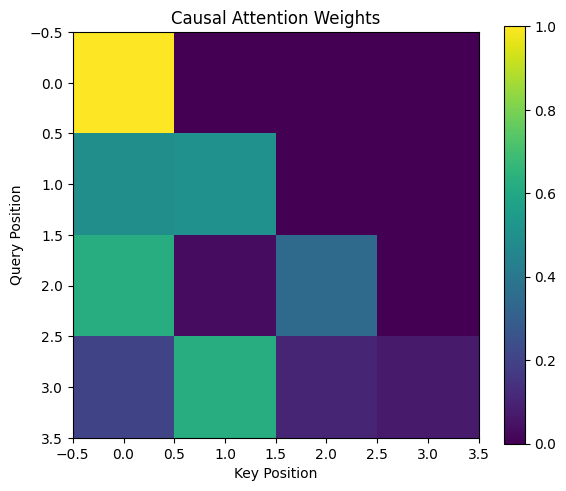

In [5]:
# =============================================
# TODO: Visualize the causal attention weights
# =============================================
# Hint: use plt.imshow() on weights_masked[0].detach().numpy()
# Add plt.colorbar(), plt.title(), plt.xlabel(), plt.ylabel()

# YOUR CODE HERE
plt.figure(figsize=(6, 5))
plt.imshow(weights_masked[0].detach().cpu().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Causal Attention Weights")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.tight_layout()
plt.show()

---
### Exercise 1.3: Why Do We Scale by $\sqrt{d_k}$?

**Task (Conceptual — answer in the markdown cell below)**:

1. What happens to the magnitude of the dot products $QK^T$ as $d_k$ grows large?
2. How does this affect the softmax output?
3. Why does dividing by $\sqrt{d_k}$ fix the problem?

**Your Answer:**

1. Dot product magnitude: For independent components with zero mean and unit variance, the variance of the dot product grows proportionally to $d_k$, pushing the magnitudes to scale on    the order of $\sqrt{d_k}$.
2. Softmax effect: Large input values force the softmax function into regions with extremely small gradients, resulting in vanishing gradients during backpropagation.
3. Scaling fix: Dividing by $\sqrt{d_k}$ normalizes the variance of the attention scores back to approximately $1$, keeping the softmax function within an active, well-behaved  gradient regime.

---
## Part 2: Multi-Head Attention

### Concept Recap

Instead of performing a single attention function, **Multi-Head Attention** runs $h$ attention heads in parallel, each with its own learned projection:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O$$

where $\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$

This allows the model to attend to information from different representation subspaces at different positions.

---
### Exercise 2.1: Implement Multi-Head Attention

**Task**: Complete the `MultiHeadAttention` class below.

Steps:
1. Create linear projections for Q, K, V, and the output.
2. In `forward()`, project Q, K, V, then reshape to split into heads.
3. Apply `scaled_dot_product_attention` to each head.
4. Concatenate heads and apply the output projection.

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        """
        Args:
            d_model: Model dimension (e.g., 512)
            num_heads: Number of attention heads (e.g., 8)
        """
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension per head

        # ======================================================
        # TODO: Create four linear layers (no bias for simplicity)
        # ======================================================
        # self.W_q = ...  # Linear(d_model, d_model)
        # self.W_k = ...  # Linear(d_model, d_model)
        # self.W_v = ...  # Linear(d_model, d_model)
        # self.W_o = ...  # Linear(d_model, d_model)

        # YOUR CODE HERE
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, Q, K, V, mask=None):
        """
        Args:
            Q, K, V: Tensors of shape (batch_size, seq_len, d_model)
            mask: Optional mask

        Returns:
            output: (batch_size, seq_len, d_model)
            attention_weights: (batch_size, num_heads, seq_len, seq_len)
        """
        batch_size = Q.size(0)

        # ================================================================
        # TODO: Complete the forward pass
        # ================================================================

        # Step 1: Linear projections
        # Q = self.W_q(Q)  ... same for K, V
        # YOUR CODE HERE
        Q = self.W_q(Q)
        K = self.W_k(K)
        V = self.W_v(V)

        # Step 2: Reshape to (batch_size, num_heads, seq_len, d_k)
        # Hint: use .view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        # YOUR CODE HERE
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Step 3: Apply scaled_dot_product_attention
        # attn_output, attention_weights = scaled_dot_product_attention(Q, K, V, mask)
        # YOUR CODE HERE
        if mask is not None and mask.dim() == 2:
            mask = mask.unsqueeze(0).unsqueeze(0)

        attn_output, attention_weights = scaled_dot_product_attention(Q, K, V, mask=mask)

        # Step 4: Concatenate heads
        # Hint: transpose back and use .contiguous().view(batch_size, -1, self.d_model)
        # YOUR CODE HERE
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # Step 5: Final linear projection
        # output = self.W_o(attn_output)
        # YOUR CODE HERE
        output = self.W_o(attn_output)

        return output, attention_weights

#### ✅ Test 2.1 — Verify Multi-Head Attention

In [7]:
torch.manual_seed(42)
d_model, num_heads, seq_len, batch_size = 64, 8, 10, 2

mha = MultiHeadAttention(d_model, num_heads)
x = torch.randn(batch_size, seq_len, d_model)

out_mha, attn_w = mha(x, x, x)  # Self-attention: Q=K=V=x

assert out_mha.shape == (batch_size, seq_len, d_model), f"Output shape wrong: {out_mha.shape}"
assert attn_w.shape == (batch_size, num_heads, seq_len, seq_len), f"Weights shape wrong: {attn_w.shape}"
print(f"✅ Test 2.1 Passed — MHA output shape: {out_mha.shape}, weights shape: {attn_w.shape}")

✅ Test 2.1 Passed — MHA output shape: torch.Size([2, 10, 64]), weights shape: torch.Size([2, 8, 10, 10])


---
### Exercise 2.2: Conceptual Questions on Multi-Head Attention

**Task (answer below)**:

1. If `d_model = 512` and `num_heads = 8`, what is `d_k` (dimension per head)?
2. Why is Multi-Head Attention better than single-head attention with the same total dimension?
3. In **self-attention**, Q, K, V all come from the same input. In **cross-attention**, where do Q, K, V come from respectively?

**Your Answer:**

1. $d_k = d_{\text{model}} / h = 512 / 8 = 64$.
2. Multi-Head Attention allows the model to jointly attend to information from different representation subspaces at different positions simultaneously (e.g., syntactic vs. semantic relationships), whereas a single head averages these relationships into one subspace.
3. In cross-attention, $Q$ comes from the target sequence (decoder representation), while $K$ and $V$ come from the source sequence (encoder output representations).

---
## Part 3: Positional Encoding

### Concept Recap

Since the Transformer has no recurrence or convolution, it needs **Positional Encoding** to inject information about the position of tokens in the sequence.

The original paper uses sinusoidal positional encoding:

$$PE_{(pos, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

---
### Exercise 3.1: Implement Sinusoidal Positional Encoding

**Task**: Complete the `PositionalEncoding` class.

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        # =============================================
        # TODO: Create the positional encoding matrix
        # =============================================
        pe = torch.zeros(max_len, d_model)

        # Step 1: Create a position vector: [0, 1, 2, ..., max_len-1] of shape (max_len, 1)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # YOUR CODE HERE

        # Step 2: Create the division term: 10000^(2i/d_model)
        # Hint: use torch.exp and torch.arange
        # div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))  # YOUR CODE HERE

        # Step 3: Apply sin to even indices and cos to odd indices
        # pe[:, 0::2] = torch.sin(position * div_term)
        # pe[:, 1::2] = torch.cos(position * div_term)
        # YOUR CODE HERE
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension and register as buffer (not a parameter)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len, d_model)
        Returns:
            x + positional encoding (same shape)
        """
        # =============================================
        # TODO: Add positional encoding to input
        # =============================================
        # Hint: x = x + self.pe[:, :x.size(1), :]
        # YOUR CODE HERE
        x = x + self.pe[:, :x.size(1), :]

        return x

#### ✅ Test 3.1 — Verify Positional Encoding

In [9]:
d_model_pe = 64
pe_layer = PositionalEncoding(d_model_pe)
x_test = torch.zeros(1, 20, d_model_pe)  # All zeros

out_pe = pe_layer(x_test)

assert out_pe.shape == (1, 20, d_model_pe), f"Shape wrong: {out_pe.shape}"
assert not torch.allclose(out_pe, x_test), "PE should modify the zero input"
# Check sin/cos pattern: position 0, dim 0 should be sin(0)=0
assert abs(out_pe[0, 0, 0].item()) < 1e-5, f"PE[0,0] should be sin(0)=0, got {out_pe[0,0,0].item()}"
# position 0, dim 1 should be cos(0)=1
assert abs(out_pe[0, 0, 1].item() - 1.0) < 1e-5, f"PE[0,1] should be cos(0)=1, got {out_pe[0,0,1].item()}"
print("✅ Test 3.1 Passed — Positional encoding works correctly!")

✅ Test 3.1 Passed — Positional encoding works correctly!


---
### Exercise 3.2: Visualize Positional Encoding

**Task**: Plot the positional encoding matrix as a heatmap.

1. Create a `PositionalEncoding` with `d_model=64` and extract the PE matrix for the first 50 positions.
2. Plot it using `plt.imshow()` with `aspect='auto'`.
3. Add axis labels: "Position" (y-axis) and "Dimension" (x-axis).

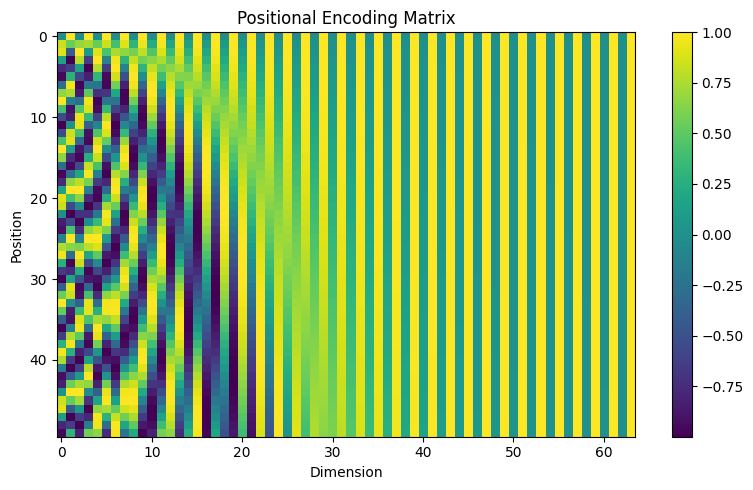

In [10]:
# =============================================
# TODO: Visualize positional encoding heatmap
# =============================================
# Hint: pe_matrix = pe_layer.pe[0, :50, :].numpy()

# YOUR CODE HERE
pe_layer = PositionalEncoding(d_model=64, max_len=50)
pe_matrix = pe_layer.pe[0, :50, :].detach().cpu().numpy()

plt.figure(figsize=(8, 5))
plt.imshow(pe_matrix, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Positional Encoding Matrix")
plt.xlabel("Dimension")
plt.ylabel("Position")
plt.tight_layout()
plt.show()

---
## Part 4: Feed-Forward Network & Layer Normalization

### Concept Recap

Each Transformer sub-layer is followed by:
1. A **Position-wise Feed-Forward Network** (two linear layers with ReLU):
   $$\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$
   The inner dimension $d_{ff}$ is typically 4× $d_{model}$.

2. **Residual Connection + Layer Normalization**:
   $$\text{output} = \text{LayerNorm}(x + \text{SubLayer}(x))$$

---
### Exercise 4.1: Implement the Feed-Forward Network

**Task**: Complete the `PositionwiseFeedForward` class.

In [11]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        """
        Args:
            d_model: Model dimension
            d_ff: Feed-forward inner dimension (typically 4 * d_model)
            dropout: Dropout rate
        """
        super().__init__()

        # =============================================
        # TODO: Create two linear layers and a dropout
        # =============================================
        # self.linear1 = nn.Linear(d_model, d_ff)
        # self.linear2 = nn.Linear(d_ff, d_model)
        # self.dropout = nn.Dropout(dropout)

        # YOUR CODE HERE
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_len, d_model)
        Returns:
            output: (batch_size, seq_len, d_model)
        """
        # =============================================
        # TODO: Apply linear1 -> ReLU -> dropout -> linear2
        # =============================================

        # YOUR CODE HERE
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

#### ✅ Test 4.1 — Verify Feed-Forward Network

In [12]:
torch.manual_seed(42)
ffn = PositionwiseFeedForward(d_model=64, d_ff=256)
ffn.eval()  # Disable dropout for testing

x_ffn = torch.randn(2, 10, 64)
out_ffn = ffn(x_ffn)

assert out_ffn.shape == (2, 10, 64), f"Shape wrong: {out_ffn.shape}"
assert not torch.allclose(out_ffn, x_ffn), "FFN should transform the input"
print(f"✅ Test 4.1 Passed — FFN output shape: {out_ffn.shape}")

✅ Test 4.1 Passed — FFN output shape: torch.Size([2, 10, 64])


---
## Part 5: Transformer Encoder Block

### Concept Recap

A single Transformer **Encoder Block** consists of:
1. Multi-Head **Self-Attention** + Residual + LayerNorm
2. **Feed-Forward Network** + Residual + LayerNorm

```
Input
  │
  ├──> Multi-Head Self-Attention ──> Add & LayerNorm
  │
  ├──> Feed-Forward Network ──────> Add & LayerNorm
  │
Output
```

---
### Exercise 5.1: Implement the Encoder Block

**Task**: Complete the `EncoderBlock` class using your `MultiHeadAttention` and `PositionwiseFeedForward`.

In [13]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        # =============================================
        # TODO: Create the sublayers
        # =============================================
        # self.self_attn = MultiHeadAttention(d_model, num_heads)
        # self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        # self.norm1 = nn.LayerNorm(d_model)
        # self.norm2 = nn.LayerNorm(d_model)
        # self.dropout1 = nn.Dropout(dropout)
        # self.dropout2 = nn.Dropout(dropout)

        # YOUR CODE HERE
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Args:
            x: (batch_size, seq_len, d_model)
            mask: Optional attention mask

        Returns:
            output: (batch_size, seq_len, d_model)
        """
        # =============================================
        # TODO: Implement the encoder block
        # =============================================
        # Step 1: Self-attention + residual + norm
        # attn_output, _ = self.self_attn(x, x, x, mask)
        # x = self.norm1(x + self.dropout1(attn_output))

        # Step 2: FFN + residual + norm
        # ffn_output = self.ffn(x)
        # x = self.norm2(x + self.dropout2(ffn_output))

        # YOUR CODE HERE
        attn_output, _ = self.self_attn(x, x, x, mask=mask)
        x = self.norm1(x + self.dropout1(attn_output))

        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_output))

        return x

#### ✅ Test 5.1 — Verify Encoder Block

In [14]:
torch.manual_seed(42)
enc_block = EncoderBlock(d_model=64, num_heads=8, d_ff=256)
enc_block.eval()

x_enc = torch.randn(2, 10, 64)
out_enc = enc_block(x_enc)

assert out_enc.shape == (2, 10, 64), f"Shape wrong: {out_enc.shape}"
print(f"✅ Test 5.1 Passed — Encoder block output: {out_enc.shape}")

✅ Test 5.1 Passed — Encoder block output: torch.Size([2, 10, 64])


---
## Part 6: Transformer Decoder Block

### Concept Recap

A single Transformer **Decoder Block** consists of:
1. **Masked** Multi-Head Self-Attention + Residual + LayerNorm
2. **Cross-Attention** (attends to encoder output) + Residual + LayerNorm
3. Feed-Forward Network + Residual + LayerNorm

The masked self-attention uses a **causal mask** so each position can only attend to earlier positions.

---
### Exercise 6.1: Implement the Decoder Block

**Task**: Complete the `DecoderBlock` class.

In [15]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        # =============================================
        # TODO: Create sublayers
        # =============================================
        # Masked self-attention
        # self.self_attn = MultiHeadAttention(d_model, num_heads)

        # Cross-attention (attends to encoder output)
        # self.cross_attn = MultiHeadAttention(d_model, num_heads)

        # Feed-forward
        # self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)

        # Layer norms (3 of them) and dropouts (3 of them)
        # self.norm1 = nn.LayerNorm(d_model)
        # self.norm2 = nn.LayerNorm(d_model)
        # self.norm3 = nn.LayerNorm(d_model)
        # self.dropout1 = nn.Dropout(dropout)
        # self.dropout2 = nn.Dropout(dropout)
        # self.dropout3 = nn.Dropout(dropout)

        # YOUR CODE HERE
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        """
        Args:
            x: Target sequence (batch_size, tgt_len, d_model)
            encoder_output: Encoder output (batch_size, src_len, d_model)
            src_mask: Mask for encoder output (padding mask)
            tgt_mask: Causal mask for target (look-ahead mask)

        Returns:
            output: (batch_size, tgt_len, d_model)
        """
        # =============================================
        # TODO: Implement the decoder block
        # =============================================

        # Step 1: Masked self-attention (Q=K=V=x, with tgt_mask)
        # YOUR CODE HERE
        self_attn_out, _ = self.self_attn(x, x, x, mask=tgt_mask)
        x = self.norm1(x + self.dropout1(self_attn_out))

        # Step 2: Cross-attention (Q=x, K=V=encoder_output, with src_mask)
        # YOUR CODE HERE
        cross_attn_out, _ = self.cross_attn(x, encoder_output, encoder_output, mask=src_mask)
        x = self.norm2(x + self.dropout2(cross_attn_out))

        # Step 3: Feed-forward + residual + norm
        # YOUR CODE HERE
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout3(ffn_out))

        return x

#### ✅ Test 6.1 — Verify Decoder Block

In [16]:
torch.manual_seed(42)
dec_block = DecoderBlock(d_model=64, num_heads=8, d_ff=256)
dec_block.eval()

tgt = torch.randn(2, 8, 64)   # target sequence
enc_out = torch.randn(2, 10, 64)  # encoder output (source)

# Create causal mask for target
tgt_len = tgt.size(1)
tgt_mask = torch.triu(torch.ones(tgt_len, tgt_len, dtype=torch.bool), diagonal=1)

out_dec = dec_block(tgt, enc_out, tgt_mask=tgt_mask)

assert out_dec.shape == (2, 8, 64), f"Shape wrong: {out_dec.shape}"
print(f"✅ Test 6.1 Passed — Decoder block output: {out_dec.shape}")

✅ Test 6.1 Passed — Decoder block output: torch.Size([2, 8, 64])


---
## Part 7: Full Transformer Model (Encoder-Decoder)

### Concept Recap

The complete Transformer stacks $N$ encoder blocks and $N$ decoder blocks:

```
Source Tokens ──> Embedding + PE ──> [Encoder × N] ──> Encoder Output
                                                           │
Target Tokens ──> Embedding + PE ──> [Decoder × N] ──> Linear ──> Softmax ──> Output Probs
```

---
### Exercise 7.1: Assemble the Full Transformer

**Task**: Complete the `Transformer` class by combining all the components.

In [17]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=64, num_heads=8,
                 d_ff=256, num_layers=2, max_len=100, dropout=0.1):
        super().__init__()

        # =============================================
        # TODO: Create all components
        # =============================================

        # Source and target embeddings
        # self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        # self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding
        # self.positional_encoding = PositionalEncoding(d_model, max_len)

        # Encoder: stack of N EncoderBlocks
        # self.encoder_layers = nn.ModuleList([EncoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        # Decoder: stack of N DecoderBlocks
        # self.decoder_layers = nn.ModuleList([DecoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        # Final linear layer to project to vocabulary
        # self.fc_out = nn.Linear(d_model, tgt_vocab_size)

        # self.dropout = nn.Dropout(dropout)

        # YOUR CODE HERE
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)

        self.positional_encoding = PositionalEncoding(d_model, max_len)

        self.encoder_layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def encode(self, src, src_mask=None):
        """
        Encode source sequence.

        Args:
            src: Source token IDs (batch_size, src_len)
            src_mask: Optional source mask
        Returns:
            encoder output: (batch_size, src_len, d_model)
        """
        # =============================================
        # TODO: Embed, add PE, then pass through encoder layers
        # =============================================
        # x = self.dropout(self.positional_encoding(self.src_embedding(src)))
        # for layer in self.encoder_layers:
        #     x = layer(x, src_mask)
        # return x

        # YOUR CODE HERE
        x = self.dropout(self.positional_encoding(self.src_embedding(src)))
        for layer in self.encoder_layers:
            x = layer(x, mask=src_mask)
        return x

    def decode(self, tgt, encoder_output, src_mask=None, tgt_mask=None):
        """
        Decode target sequence.

        Args:
            tgt: Target token IDs (batch_size, tgt_len)
            encoder_output: Output from encoder
            src_mask: Source mask
            tgt_mask: Target causal mask
        Returns:
            decoder output: (batch_size, tgt_len, d_model)
        """
        # =============================================
        # TODO: Embed, add PE, then pass through decoder layers
        # =============================================

        # YOUR CODE HERE
        x = self.dropout(self.positional_encoding(self.tgt_embedding(tgt)))
        for layer in self.decoder_layers:
            x = layer(x, encoder_output, src_mask=src_mask, tgt_mask=tgt_mask)
        return x

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        """
        Full forward pass.

        Args:
            src: Source token IDs (batch_size, src_len)
            tgt: Target token IDs (batch_size, tgt_len)
        Returns:
            output logits: (batch_size, tgt_len, tgt_vocab_size)
        """
        # =============================================
        # TODO: Encode, then decode, then project to vocab
        # =============================================

        # YOUR CODE HERE
        encoder_output = self.encode(src, src_mask=src_mask)
        decoder_output = self.decode(tgt, encoder_output, src_mask=src_mask, tgt_mask=tgt_mask)
        return self.fc_out(decoder_output)

#### ✅ Test 7.1 — Verify Full Transformer

In [18]:
torch.manual_seed(42)

src_vocab, tgt_vocab = 1000, 1500
transformer = Transformer(src_vocab, tgt_vocab, d_model=64, num_heads=8, d_ff=256, num_layers=2)
transformer.eval()

# Fake source and target token IDs
src_tokens = torch.randint(0, src_vocab, (2, 12))  # batch=2, src_len=12
tgt_tokens = torch.randint(0, tgt_vocab, (2, 8))   # batch=2, tgt_len=8

# Create causal mask for target
tgt_len = tgt_tokens.size(1)
tgt_mask = torch.triu(torch.ones(tgt_len, tgt_len, dtype=torch.bool), diagonal=1)

logits = transformer(src_tokens, tgt_tokens, tgt_mask=tgt_mask)

assert logits.shape == (2, 8, tgt_vocab), f"Output shape wrong: {logits.shape}"
print(f"✅ Test 7.1 Passed — Transformer output shape: {logits.shape}")

# Count parameters
total_params = sum(p.numel() for p in transformer.parameters())
print(f"📊 Total parameters: {total_params:,}")

✅ Test 7.1 Passed — Transformer output shape: torch.Size([2, 8, 1500])
📊 Total parameters: 489,436


---
## Part 8: Conceptual Questions — Transformer Architecture

**Task (answer all questions below)**:

### Q1: Encoder vs Decoder
What is the key structural difference between an Encoder block and a Decoder block?

### Q2: Masking
Explain the two types of masks used in the Transformer:
- **Padding mask**: Why is it needed? When is it used?
- **Causal (look-ahead) mask**: Why is it needed? When is it used?

### Q3: Encoder-Only vs Decoder-Only vs Encoder-Decoder
Give an example model for each architecture variant and a task it excels at:
- Encoder-only: (model? task?)
- Decoder-only: (model? task?)
- Encoder-Decoder: (model? task?)

### Q4: Self-Attention Complexity
What is the time and memory complexity of self-attention with respect to sequence length $n$? Why does this create problems for very long sequences?

**Your Answers:**

**Q1:** (Encoder vs Decoder): The Encoder uses standard bidirectional self-attention to contextualize the entire input. The Decoder contains an additional sub-layer for cross-attention (attending to encoder outputs) and uses masked (causal) self-attention to prevent tokens from attending to future positions.

**Q2:** (Masking):Padding mask: Zeroes out padding tokens (<PAD>) so they do not receive or contribute attention weight. Used in both encoder and decoder inputs whenever batches contain variable-length sequences.Causal (look-ahead) mask: Masks future token positions (setting logits to $-\infty$) during autoregressive generation/training so position $t$ can only attend to positions $\le t$.

**Q3:** (Architectures):Encoder-only: BERT / RoBERTa — Extractive Question Answering, Sentiment Analysis, Token Classification.Decoder-only: GPT-4 / LLaMA — Autoregressive Text Generation, Code Completion.Encoder-Decoder: T5 / BART — Abstractive Summarization, Machine Translation.

**Q4:** (Complexity): Computing $QK^T$ requires $\mathcal{O}(n^2 \cdot d)$ time and $\mathcal{O}(n^2)$ memory to store the full attention matrix. As sequence length $n$ increases, quadratic memory and compute overhead quickly become the primary operational bottleneck.

---
## Part 9: Using Pre-Trained Transformers with HuggingFace 🤗

Now let's use a real pre-trained Transformer model for a practical task.

---
### Exercise 9.1: Text Summarization with a Pre-Trained T5 Model

**Task**: Use the HuggingFace `transformers` library to summarize a text passage.

Steps:
1. Load the `t5-small` model and tokenizer.
2. Tokenize the input text (prefix it with `"summarize: "`).
3. Generate a summary using `model.generate()`.
4. Decode and print the summary.

In [19]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

# Input text to summarize
text = """
The Transformer architecture, introduced in the landmark paper "Attention Is All You Need" 
by Vaswani et al. in 2017, revolutionized natural language processing by replacing recurrent 
and convolutional layers entirely with self-attention mechanisms. The key innovation was the 
multi-head attention mechanism, which allows the model to jointly attend to information from 
different representation subspaces at different positions. Combined with positional encodings 
to inject sequence order information, the Transformer achieved state-of-the-art results on 
machine translation benchmarks while being significantly more parallelizable than previous 
architectures. This architecture became the foundation for subsequent breakthroughs including 
BERT, GPT, T5, and many other large language models that have transformed the field of AI.
"""

# =============================================
# TODO: Summarize the text using T5-small
# =============================================

# Step 1: Load model and tokenizer
# tokenizer = T5Tokenizer.from_pretrained("t5-small")
# model = T5ForConditionalGeneration.from_pretrained("t5-small")
# YOUR CODE HERE

# Step 2: Tokenize (don't forget the "summarize: " prefix!)
# input_ids = tokenizer.encode("summarize: " + text, return_tensors="pt", max_length=512, truncation=True)
# YOUR CODE HERE

# Step 3: Generate summary
# summary_ids = model.generate(input_ids, max_length=80, num_beams=4, early_stopping=True)
# YOUR CODE HERE

# Step 4: Decode and print
# summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
# print("Summary:", summary)
# YOUR CODE HERE
tokenizer = T5Tokenizer.from_pretrained("t5-small")
model = T5ForConditionalGeneration.from_pretrained("t5-small")

input_ids = tokenizer.encode("summarize: " + text.strip(), return_tensors="pt", max_length=512, truncation=True)
summary_ids = model.generate(input_ids, max_length=80, num_beams=4, early_stopping=True)

summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
print("Summary:", summary)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--t5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order t

Summary: the Transformer architecture was introduced in the landmark paper "Attention Is All You Need" the multi-head attention mechanism allows the model to jointly attend to information from different representation subspaces at different positions. this architecture became the foundation for subsequent breakthroughs including BERT, GPT, T5 and many other large language models.


---
### Exercise 9.2: Explore Attention Patterns of a Pre-Trained Model

**Task**: Visualize the attention weights from a pre-trained BERT model.

Steps:
1. Load `bert-base-uncased` with `output_attentions=True`.
2. Tokenize a sentence.
3. Run a forward pass and extract attention weights.
4. Plot a heatmap of one attention head from the last layer.

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3349.94it/s]
[transformers] BertModel LOAD REPO

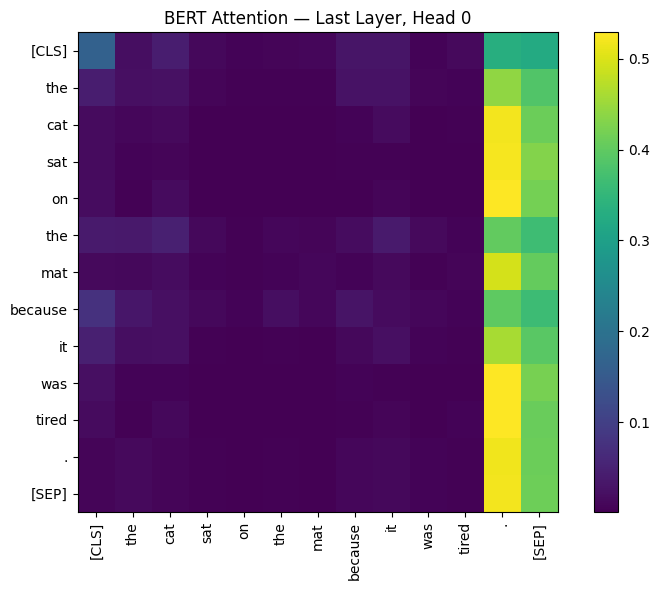

In [20]:
from transformers import BertModel, BertTokenizer

sentence = "The cat sat on the mat because it was tired."

# =============================================
# TODO: Visualize BERT attention patterns
# =============================================

# Step 1: Load model (with output_attentions=True) and tokenizer
# tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
# model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
# YOUR CODE HERE

# Step 2: Tokenize and get token strings for axis labels
# inputs = tokenizer(sentence, return_tensors="pt")
# tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
# YOUR CODE HERE

# Step 3: Forward pass (no gradient needed)
# with torch.no_grad():
#     outputs = model(**inputs)
#     attentions = outputs.attentions  # tuple of (batch, heads, seq_len, seq_len)
# YOUR CODE HERE

# Step 4: Plot attention heatmap (last layer, head 0)
# attn = attentions[-1][0, 0].numpy()  # last layer, first head
# plt.figure(figsize=(8, 6))
# plt.imshow(attn, cmap="viridis")
# plt.xticks(range(len(tokens)), tokens, rotation=90)
# plt.yticks(range(len(tokens)), tokens)
# plt.colorbar()
# plt.title("BERT Attention — Last Layer, Head 0")
# plt.tight_layout()
# YOUR CODE HERE
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)

inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions

attn = attentions[-1][0, 0].cpu().numpy()

plt.figure(figsize=(8, 6))
plt.imshow(attn, cmap="viridis")
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.colorbar()
plt.title("BERT Attention — Last Layer, Head 0")
plt.tight_layout()
plt.show()

---
## Part 10: Bonus Challenges 🏆

### Bonus 10.1: Implement a Helper Function to Generate Causal Masks

**Task**: Write a function that generates a causal (look-ahead) mask for a given sequence length.

In [21]:
def generate_causal_mask(size):
    """
    Generate a causal (look-ahead) mask.

    Args:
        size: Sequence length

    Returns:
        mask: Boolean tensor of shape (size, size) where True = masked position
              (positions that should NOT be attended to)

    Example for size=4:
        [[False,  True,  True,  True],
         [False, False,  True,  True],
         [False, False, False,  True],
         [False, False, False, False]]
    """
    # =============================================
    # TODO: Generate the causal mask
    # =============================================
    # Hint: use torch.triu with diagonal=1

    # YOUR CODE HERE
    return torch.triu(torch.ones(size, size, dtype=torch.bool), diagonal=1)

In [22]:
# ✅ Test Bonus 10.1
mask_4 = generate_causal_mask(4)
expected = torch.tensor([
    [False, True,  True,  True],
    [False, False, True,  True],
    [False, False, False, True],
    [False, False, False, False]
])
assert torch.equal(mask_4, expected), f"Mask incorrect:\n{mask_4}"
print("✅ Bonus 10.1 Passed — Causal mask generation works!")

✅ Bonus 10.1 Passed — Causal mask generation works!


---
### Bonus 10.2: Compare Transformer Parameter Count

**Task**: Create Transformer models with different configurations and compare their parameter counts. Fill in the table below.

| Config | d_model | num_heads | d_ff | num_layers | Total Params |
|--------|---------|-----------|------|------------|-------------|
| Tiny   | 64      | 4         | 256  | 2          | ?           |
| Small  | 128     | 8         | 512  | 4          | ?           |
| Medium | 256     | 8         | 1024 | 6          | ?           |

In [23]:
# =============================================
# TODO: Create 3 transformers and count params
# =============================================
configs = [
    {"name": "Tiny",   "d_model": 64,  "num_heads": 4, "d_ff": 256,  "num_layers": 2},
    {"name": "Small",  "d_model": 128, "num_heads": 8, "d_ff": 512,  "num_layers": 4},
    {"name": "Medium", "d_model": 256, "num_heads": 8, "d_ff": 1024, "num_layers": 6},
]

for cfg in configs:
    # Create transformer with src_vocab=1000, tgt_vocab=1000
    # Count and print total parameters
    # YOUR CODE HERE
    m = Transformer(
        src_vocab_size=1000,
        tgt_vocab_size=1000,
        d_model=cfg["d_model"],
        num_heads=cfg["num_heads"],
        d_ff=cfg["d_ff"],
        num_layers=cfg["num_layers"]
    )
    total = sum(p.numel() for p in m.parameters())
    print(f"| {cfg['name']:<6} | {cfg['d_model']:<7} | {cfg['num_heads']:<9} | {cfg['d_ff']:<4} | {cfg['num_layers']:<10} | {total:<12,} |")

| Tiny   | 64      | 4         | 256  | 2          | 424,936      |
| Small  | 128     | 8         | 512  | 4          | 2,230,248    |
| Medium | 256     | 8         | 1024 | 6          | 11,809,768   |


---
## 🎉 Congratulations!

You've completed the Transformer Deep Dive lab! You have:

- ✅ Built **Scaled Dot-Product Attention** from scratch
- ✅ Implemented **Multi-Head Attention**
- ✅ Created **Positional Encoding**
- ✅ Assembled a full **Encoder Block** and **Decoder Block**
- ✅ Combined everything into a complete **Transformer model**
- ✅ Used pre-trained Transformers via **HuggingFace** for real tasks

### Key Takeaways
1. The Transformer replaces recurrence with **self-attention**, enabling full parallelization.
2. **Multi-Head Attention** lets the model attend to different representation subspaces.
3. **Positional Encoding** injects sequence order since attention is position-agnostic.
4. **Residual connections** and **Layer Normalization** are critical for training deep models.
5. The Encoder-Decoder design is the foundation for models like T5, while encoder-only (BERT) and decoder-only (GPT) variants power many modern applications.